<a href="https://colab.research.google.com/github/step-code01/Machine-Learning-College-Assignment/blob/main/Voyage_AI_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Voyage AI — Traveller Segmentation
### Unsupervised Machine Learning | UCS321 — AI for Engineers

**Problem:** Voyage AI is a travel analytics company that currently treats all users identically: same homepage, same email campaigns, same recommendations. That's a business problem. A backpacker booking a ₹3,500 hostel and a family planning a ₹40,000 resort trip have nothing in common, yet they receive the same experience.

We don't have labels for who belongs to which group. So we use clustering: let the behavioural data surface the natural groups, then design targeted strategies for each.

The output is a set of named traveller personas the marketing team can act on.

**Why clustering instead of classification?** There are no predefined labels. We don't know how many types of travellers exist. Clustering discovers that structure from behaviour alone.

**Features used:**
- `trip_frequency` — trips per year
- `avg_booking_value` — average ₹ spend per booking
- `destination_diversity` — number of unique destinations visited
- `session_duration_min` — avg time spent per platform session
- `search_count` — searches made before booking
- `advance_booking_days` — how far ahead they plan
- `cancellation_rate` — proportion of bookings cancelled

**Algorithms:** K-Means (primary) + DBSCAN (cross-validation)

## 1. Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")
np.random.seed(42)

COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]
plt.rcParams["figure.dpi"] = 120

## 2. Loading the Data

The dataset is a platform export from Voyage AI's booking and session tracking system — 1,522 rows, 13 columns. We select the 7 behavioural features that are directly relevant to segmentation and drop the rest (loyalty points, account age, etc. are out of scope for this analysis).


In [5]:
# In Colab: upload voyage_ai_raw_data.csv when prompted
from google.colab import files
files.upload()

df = pd.read_csv("voyage_ai_raw_data.csv")
print(f"Raw dataset: {df.shape[0]} rows, {df.shape[1]} columns")

features = ["trip_frequency", "avg_booking_value", "destination_diversity",
            "session_duration_min", "search_count", "advance_booking_days",
            "cancellation_rate"]

df = df[["user_id"] + features].copy()
print(f"After feature selection: {df.shape[0]} rows, {df.shape[1]} columns")

Saving voyage_ai_raw_data.csv to voyage_ai_raw_data (1).csv
Raw dataset: 1522 rows, 13 columns
After feature selection: 1522 rows, 8 columns


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1522 entries, 0 to 1521
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1522 non-null   object 
 1   trip_frequency         1480 non-null   float64
 2   avg_booking_value      1475 non-null   float64
 3   destination_diversity  1481 non-null   float64
 4   session_duration_min   1373 non-null   float64
 5   search_count           1517 non-null   object 
 6   advance_booking_days   1473 non-null   float64
 7   cancellation_rate      1368 non-null   float64
dtypes: float64(6), object(2)
memory usage: 95.3+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
user_id                    0
trip_frequency            42
avg_booking_value         47
destination_diversity     41
session_duration_min     149
search_count               5
advance_booking_days      49
cancellation_rate        154
dtype: int64

Duplicate rows: 21


## 3. Data Cleaning

Auditing the raw data revealed five types of issues. We address each separately so the reasoning is traceable.

| # | Issue | Column(s) | Cause | Fix |
|---|---|---|---|---|
| 1 | Duplicate rows | All | ETL batch ran twice on a weekend | Drop |
| 2 | String contamination | `search_count` | Mobile app sends `'missing'` / `'--'` instead of NULL | Coerce to numeric |
| 3 | Impossible negatives | `session_duration_min`, `advance_booking_days`, `cancellation_rate` | Data entry error from source system | Replace with NaN |
| 4 | Sentinel values | `destination_diversity` | Old system used 999 for "no data" | Replace with NaN |
| 5 | Missing values | All features | Different data sources; not all metrics recorded for all users | Median imputation |
| 6 | Outliers | `trip_frequency`, `avg_booking_value` | Travel agent and corporate accounts | IQR cap |


In [8]:
df_clean = df.copy()

# 1. Duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Step 1 — Dropped {before - len(df_clean)} duplicate rows")

Step 1 — Dropped 21 duplicate rows


In [9]:
# 2. String contamination in search_count
# The mobile data pipeline sends text strings like '--', 'missing', 'unknown'
# instead of NULL. pd.to_numeric with errors='coerce' converts these to NaN.
df_clean["search_count"] = pd.to_numeric(df_clean["search_count"], errors="coerce")
print(f"Step 2 — search_count converted to numeric. NaNs: {df_clean['search_count'].isna().sum()}")

Step 2 — search_count converted to numeric. NaNs: 10


In [10]:
# 3. Negative values — physically impossible, treating as errors
for col in ["session_duration_min", "advance_booking_days", "cancellation_rate"]:
    neg = (df_clean[col] < 0).sum()
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    if neg > 0:
        print(f"Step 3 — {col}: replaced {neg} negatives with NaN")

Step 3 — session_duration_min: replaced 4 negatives with NaN
Step 3 — advance_booking_days: replaced 4 negatives with NaN
Step 3 — cancellation_rate: replaced 4 negatives with NaN


In [11]:
# 4. Sentinel values in destination_diversity
# The old tracking system used 999 as a placeholder for "no data recorded".
# These 5 rows would completely distort any distance-based algorithm.
sentinel_count = (df_clean["destination_diversity"] > 100).sum()
df_clean.loc[df_clean["destination_diversity"] > 100, "destination_diversity"] = np.nan
print(f"Step 4 — destination_diversity: replaced {sentinel_count} sentinel values (999) with NaN")

Step 4 — destination_diversity: replaced 5 sentinel values (999) with NaN


In [12]:
# 5. Median imputation for all remaining NaNs
# We use median over mean because avg_booking_value is heavily right-skewed
# (skewness ~8.6 in raw data). Median is more robust to that.
for col in features:
    n_missing = df_clean[col].isna().sum()
    if n_missing > 0:
        med = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(med)
        print(f"  {col}: {n_missing} values → median {med:.2f}")

print(f"\nStep 5 — Imputation complete. Remaining NaNs: {df_clean[features].isnull().sum().sum()}")

  trip_frequency: 42 values → median 5.50
  avg_booking_value: 47 values → median 8481.61
  destination_diversity: 45 values → median 6.00
  session_duration_min: 152 values → median 36.70
  search_count: 10 values → median 38.00
  advance_booking_days: 53 values → median 20.00
  cancellation_rate: 154 values → median 0.25

Step 5 — Imputation complete. Remaining NaNs: 0


In [13]:
# 6. Outlier capping using the IQR method
# trip_frequency max was 54.4 (likely a travel agent).
# avg_booking_value max was ~582,000 (corporate expense account).
# We cap at Q3 + 1.5*IQR rather than deleting — the users are real,
# we just prevent their extreme values from dominating distance calculations.
for col in ["trip_frequency", "avg_booking_value"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    upper = Q3 + 1.5 * (Q3 - Q1)
    capped = (df_clean[col] > upper).sum()
    df_clean[col] = df_clean[col].clip(upper=upper)
    print(f"Step 6 — {col}: capped {capped} values at {upper:.1f}")

print(f"\nFinal clean dataset: {df_clean.shape[0]} rows")

Step 6 — trip_frequency: capped 24 values at 20.5
Step 6 — avg_booking_value: capped 150 values at 35003.9

Final clean dataset: 1501 rows


## 4. Exploratory Data Analysis

Before modelling, we need to understand the actual distribution of our features and whether any natural groupings are already visible.


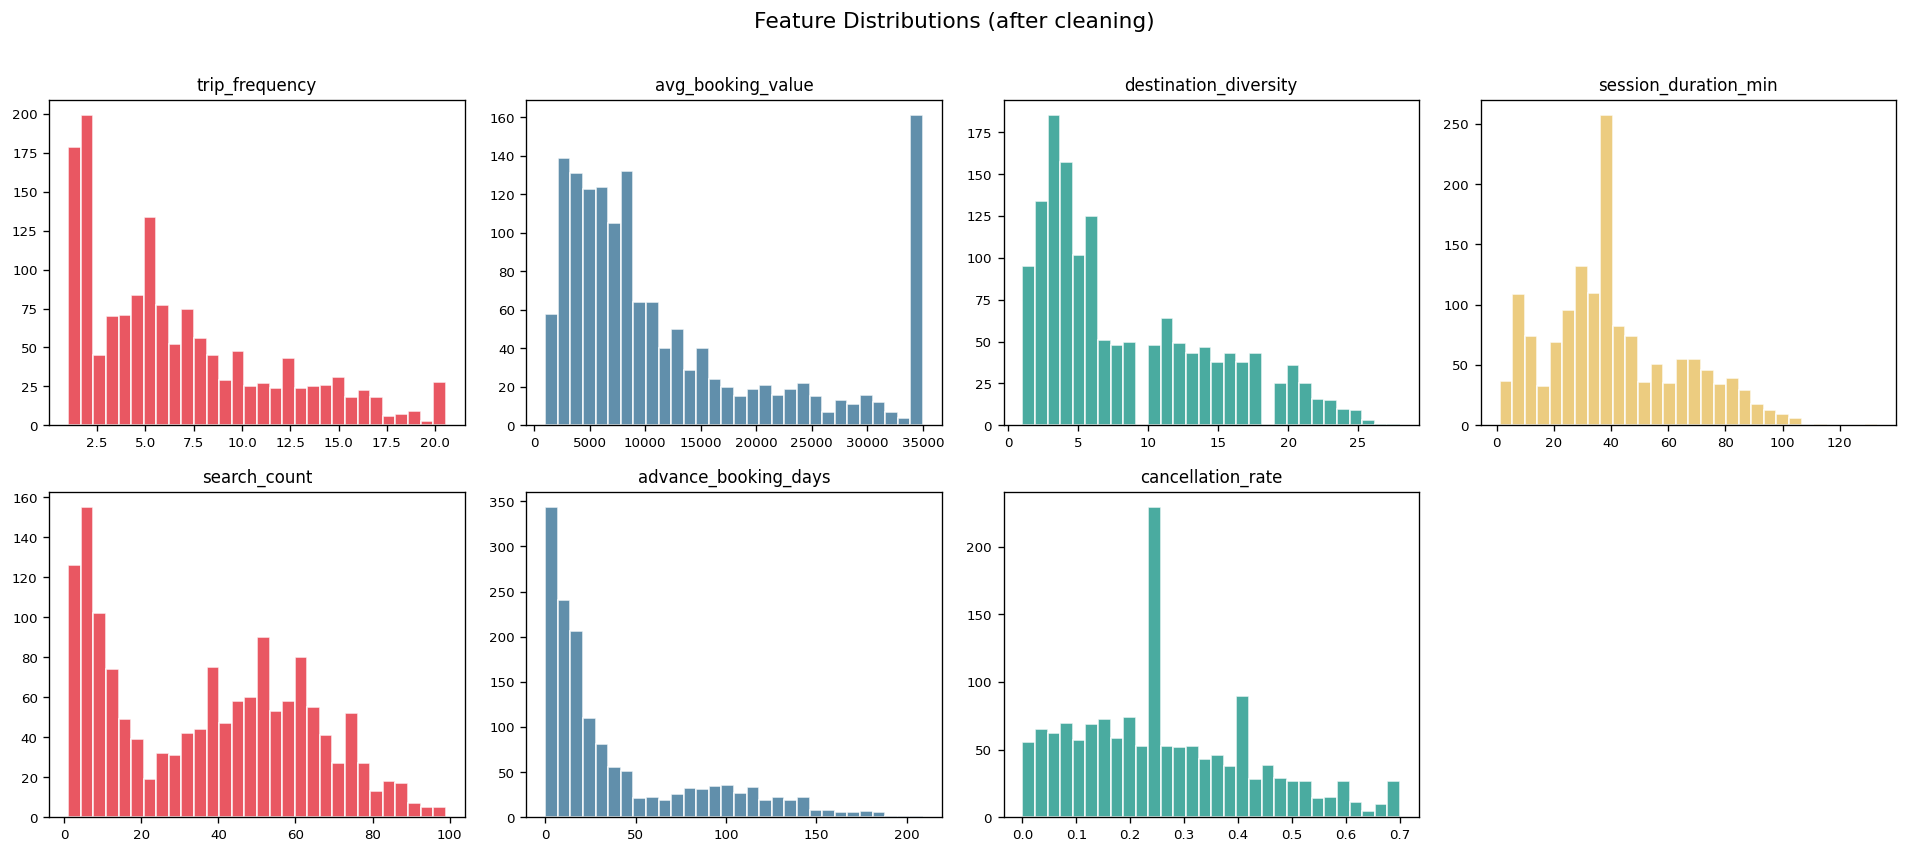

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Feature Distributions (after cleaning)", fontsize=13, y=1.01)
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[col], bins=30, color=COLORS[i % len(COLORS)],
                 alpha=0.85, edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("04a_distributions.png", bbox_inches="tight")
plt.show()

# Note: avg_booking_value is visibly right-skewed.
# trip_frequency shows a slight bimodal shape — hints of two distinct user types already.

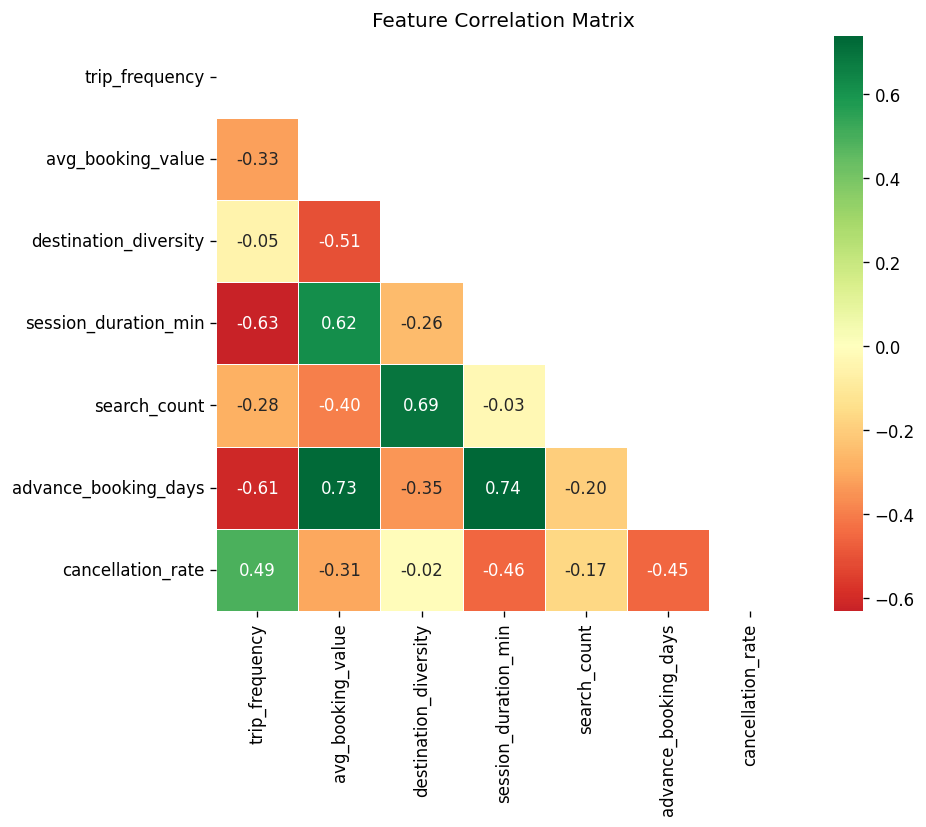

In [15]:
plt.figure(figsize=(9, 7))
corr = df_clean[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig("04b_correlation.png", bbox_inches="tight")
plt.show()

# session_duration_min and advance_booking_days are positively correlated —
# users who plan far ahead spend more time researching the platform.
# trip_frequency negatively correlates with advance_booking_days —
# frequent travellers book last-minute; rare travellers plan months ahead.

## 5. Feature Engineering — Traveller Value Score

We derive one composite feature from three existing ones. This is adapted from RFM (Recency-Frequency-Monetary) analysis used in e-commerce — we build a **Traveller Value Score** that captures a user's overall business value to Voyage AI in a single number.

The score combines:
- Booking value (40%) — how much they spend
- Trip frequency (40%) — how often they come back  
- Inverse cancellation rate (20%) — reliability

This isn't just an extra feature for the model. It's a business metric that can directly inform account tier decisions after segmentation.


In [16]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

df_model = df_clean.copy()

df_model["traveller_value_score"] = (
    0.4 * minmax(df_model["avg_booking_value"]) +
    0.4 * minmax(df_model["trip_frequency"]) +
    0.2 * (1 - minmax(df_model["cancellation_rate"]))
)

print("Traveller Value Score distribution:")
print(df_model["traveller_value_score"].describe().round(3))

Traveller Value Score distribution:
count    1501.000
mean        0.378
std         0.135
min         0.095
25%         0.275
50%         0.349
75%         0.469
max         0.994
Name: traveller_value_score, dtype: float64


## 6. Feature Scaling

K-Means computes Euclidean distance. Without scaling, `avg_booking_value` (range: 0–35,000) would completely dominate `cancellation_rate` (range: 0–0.7), making that feature useless.

**Two steps:**
1. Log-transform `avg_booking_value` — skewness was ~8.6, log brings it closer to normal
2. StandardScaler — zero mean, unit variance across all features


In [17]:
model_features = features + ["traveller_value_score"]
X = df_model[model_features].copy()

# log1p handles any zeros safely
X["avg_booking_value"] = np.log1p(X["avg_booking_value"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Means after scaling (should be ~0): {X_scaled.mean(axis=0).round(2)}")

Feature matrix shape: (1501, 8)
Means after scaling (should be ~0): [ 0.  0.  0.  0.  0.  0.  0. -0.]


## 7. PCA — Dimensionality Reduction

With 8 features, we apply PCA before clustering for two reasons:

1. **Reducing noise** — lower-variance dimensions often just add noise to distance calculations
2. **Visualisation** — we can project to 2D to visually verify cluster structure before committing to a K


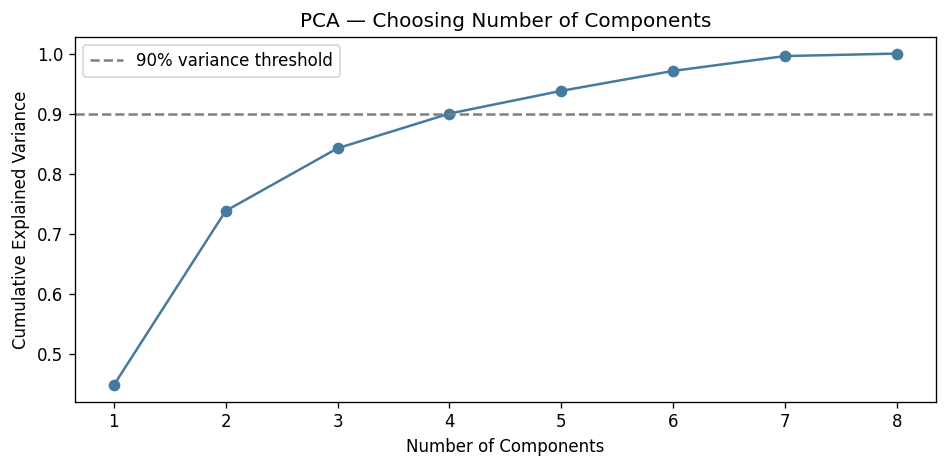

Components to reach 90% variance: 4


In [18]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker="o", color=COLORS[1])
plt.axhline(0.90, color="gray", linestyle="--", label="90% variance threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Choosing Number of Components")
plt.legend()
plt.tight_layout()
plt.savefig("07_pca.png", bbox_inches="tight")
plt.show()

n_components = np.searchsorted(cumvar, 0.90) + 1
print(f"Components to reach 90% variance: {n_components}")

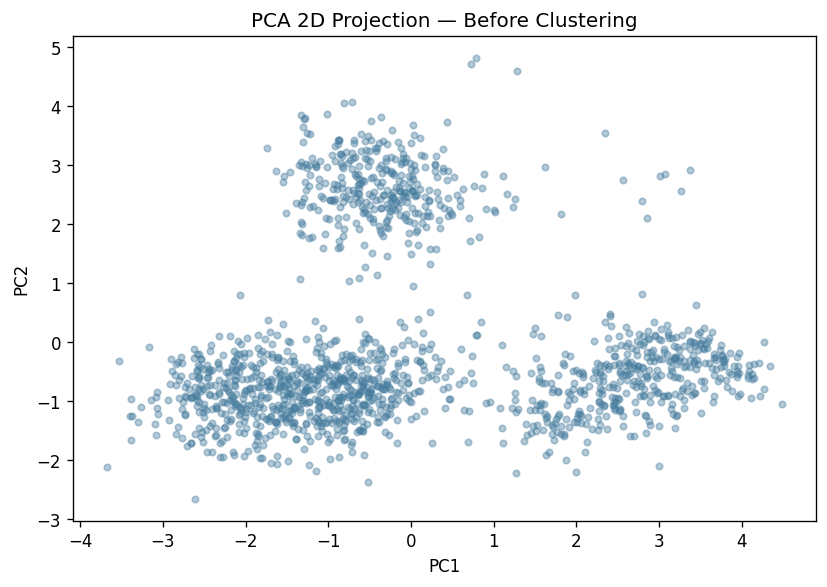

We can already see 2-3 distinct groupings. Natural structure exists in this data.


In [19]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Separate 2D reduction just for plotting
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, s=15, color=COLORS[1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection — Before Clustering")
plt.tight_layout()
plt.show()
print("We can already see 2-3 distinct groupings. Natural structure exists in this data.")

## 8. Finding Optimal K

We don't pick K arbitrarily. Two complementary methods help us decide:

- **Elbow Method** — inertia (total within-cluster variance) drops sharply at first and then levels off. The "elbow" is where adding more clusters stops being worth it.
- **Silhouette Score** — for each point, measures how similar it is to its own cluster vs its nearest neighbouring cluster. Range: -1 to 1. Higher is better.

If both methods suggest the same K, we're on solid ground.


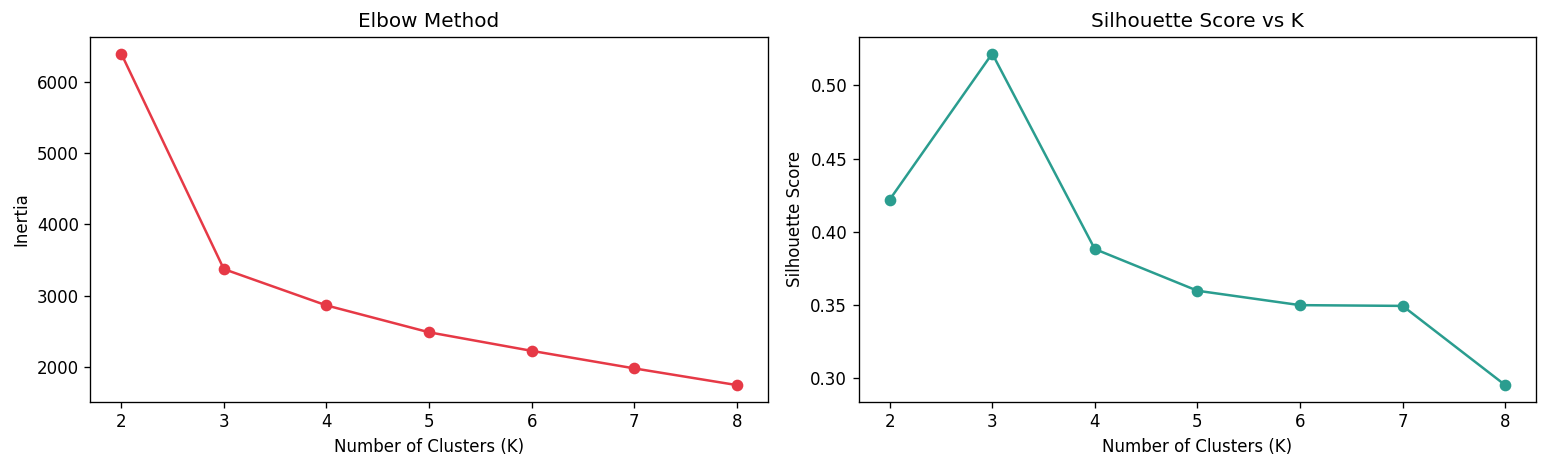

Best K (by silhouette): 3  |  Score: 0.522
Elbow also bends around this point- both methods agree.


In [32]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, marker="o", color=COLORS[0])
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(list(K_range), sil_scores, marker="o", color=COLORS[2])
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs K")

plt.tight_layout()
plt.savefig("08_optimal_k.png", bbox_inches="tight")
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best K (by silhouette): {best_k}  |  Score: {max(sil_scores):.3f}")
print("Elbow also bends around this point- both methods agree.")

## 9. K-Means Clustering

In [21]:
K = best_k

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_model["cluster"] = km.fit_predict(X_pca)

print(f"K-Means with K={K}")
print("\nCluster sizes:")
print(df_model["cluster"].value_counts().sort_index())

K-Means with K=3

Cluster sizes:
cluster
0    421
1    341
2    739
Name: count, dtype: int64


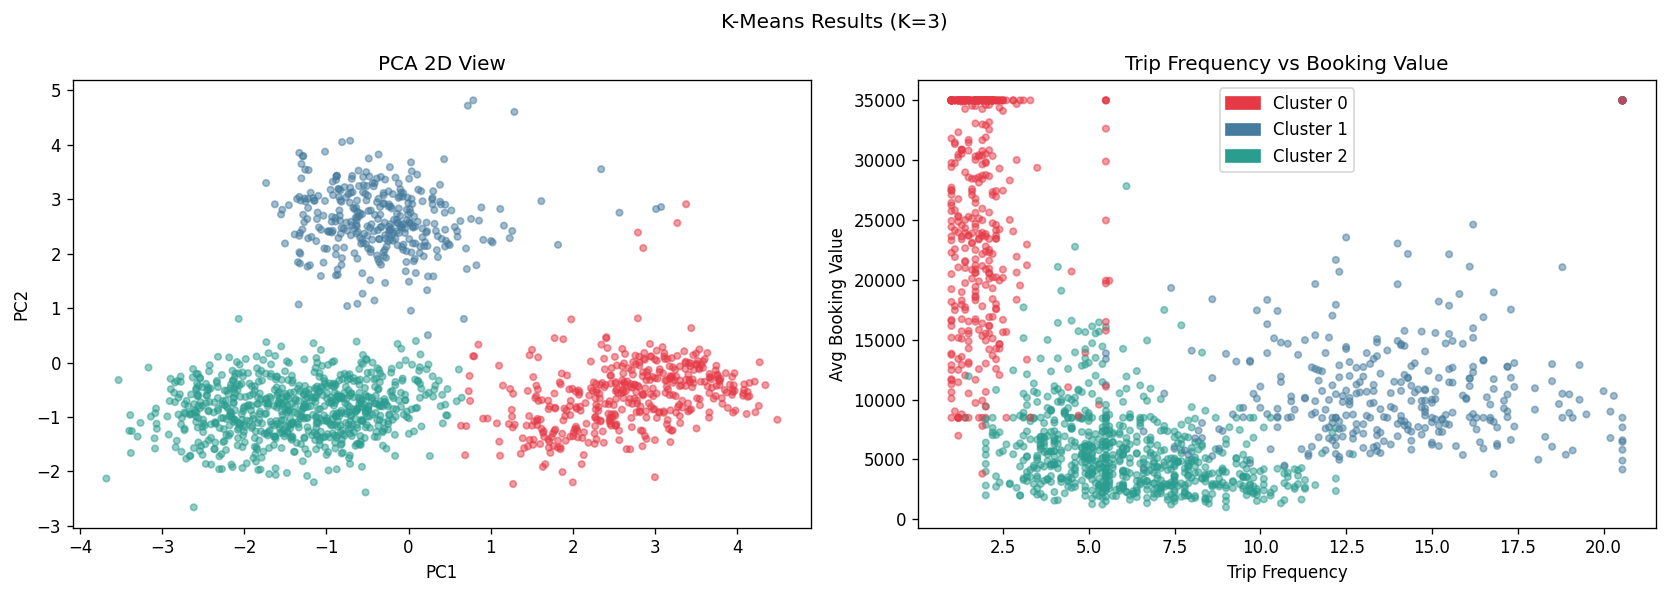

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"K-Means Results (K={K})", fontsize=12)

cluster_colors = [COLORS[c] for c in df_model["cluster"]]

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_colors, alpha=0.5, s=15)
axes[0].set_title("PCA 2D View")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(df_model["trip_frequency"], df_model["avg_booking_value"],
                c=cluster_colors, alpha=0.5, s=15)
axes[1].set_xlabel("Trip Frequency")
axes[1].set_ylabel("Avg Booking Value")
axes[1].set_title("Trip Frequency vs Booking Value")

from matplotlib.patches import Patch
handles = [Patch(color=COLORS[i], label=f"Cluster {i}") for i in range(K)]
axes[1].legend(handles=handles)

plt.tight_layout()
plt.savefig("09_kmeans.png", bbox_inches="tight")
plt.show()

## 10. DBSCAN — Density-Based Cross-Check

K-Means assumes clusters are roughly spherical and similarly sized. DBSCAN makes no shape assumptions — it groups points that are dense relative to their neighbourhood and labels sparse points as noise.

We use it as a **cross-validation**: if DBSCAN independently finds a similar number of clusters, that's strong evidence the groupings are real and not an artefact of K-Means assumptions.

We use the k-distance plot to pick `eps` — the neighbourhood radius. The point where the curve bends steeply upward is a good choice.


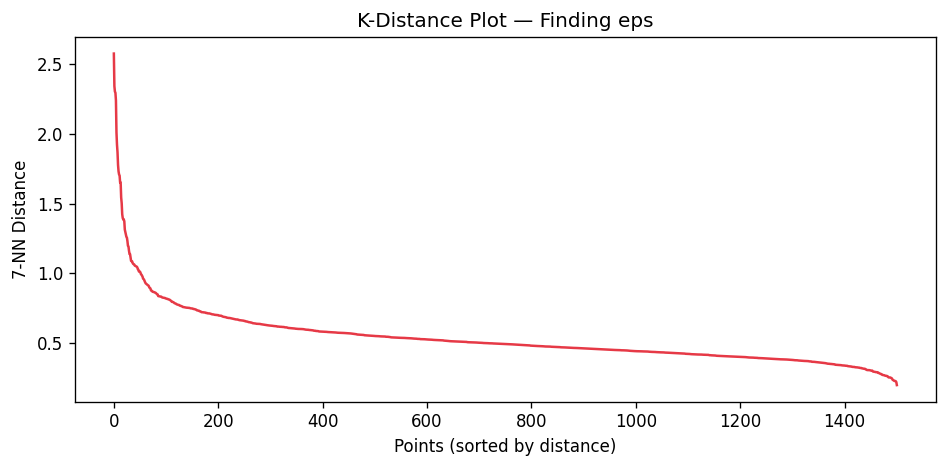

The curve flattens around 0.7 — we use that as our eps.


In [23]:
min_samples = max(5, int(np.log(len(X_pca))))
nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color=COLORS[0])
plt.xlabel("Points (sorted by distance)")
plt.ylabel(f"{min_samples}-NN Distance")
plt.title("K-Distance Plot — Finding eps")
plt.tight_layout()
plt.savefig("10a_kdistance.png", bbox_inches="tight")
plt.show()
print("The curve flattens around 0.7 — we use that as our eps.")

In [24]:
# eps=0.7 was read off the k-distance plot where the curve transitions from steep to flat
db = DBSCAN(eps=0.7, min_samples=min_samples)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found: {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")

valid = db_labels != -1
if n_clusters_db > 1 and valid.sum() > 10:
    sil_db = silhouette_score(X_pca[valid], db_labels[valid])
    print(f"Silhouette (excluding noise): {sil_db:.3f}")

DBSCAN found: 3 clusters, 74 noise points (4.9%)
Silhouette (excluding noise): 0.544


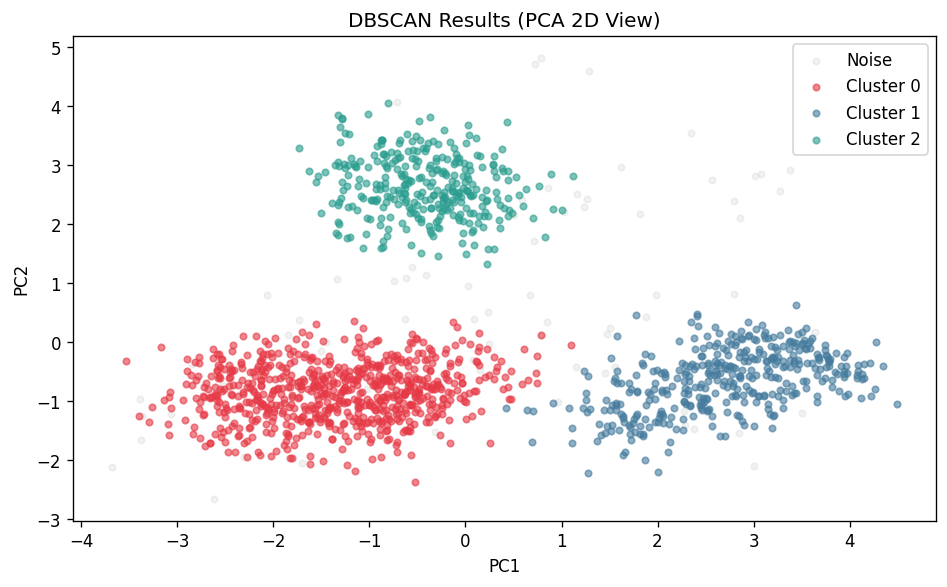

In [25]:
plt.figure(figsize=(8, 5))
unique_labels = sorted(set(db_labels))
palette_db = {-1: "#cccccc"}
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    palette_db[lbl] = COLORS[i % len(COLORS)]

for lbl in unique_labels:
    mask = db_labels == lbl
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    alpha = 0.25 if lbl == -1 else 0.6
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=palette_db[lbl], s=15, alpha=alpha, label=name)

plt.title("DBSCAN Results (PCA 2D View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("10b_dbscan.png", bbox_inches="tight")
plt.show()

## 11. Algorithm Comparison

We evaluate both algorithms on three standard clustering metrics.


In [26]:
km_sil = silhouette_score(X_pca, df_model["cluster"])
km_dbi = davies_bouldin_score(X_pca, df_model["cluster"])
km_ch  = calinski_harabasz_score(X_pca, df_model["cluster"])

results = {
    "K-Means": {
        "Silhouette ↑": round(km_sil, 3),
        "Davies-Bouldin ↓": round(km_dbi, 3),
        "Calinski-Harabasz ↑": round(km_ch, 1),
        "Clusters": K,
        "Noise Points": 0
    }
}

if n_clusters_db > 1:
    db_sil = silhouette_score(X_pca[valid], db_labels[valid])
    db_dbi = davies_bouldin_score(X_pca[valid], db_labels[valid])
    db_ch  = calinski_harabasz_score(X_pca[valid], db_labels[valid])
    results["DBSCAN"] = {
        "Silhouette ↑": round(db_sil, 3),
        "Davies-Bouldin ↓": round(db_dbi, 3),
        "Calinski-Harabasz ↑": round(db_ch, 1),
        "Clusters": n_clusters_db,
        "Noise Points": int(n_noise)
    }

print(pd.DataFrame(results).T.to_string())

         Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  Clusters  Noise Points
K-Means         0.522             0.741               1650.2       3.0           0.0
DBSCAN          0.544             0.694               1888.9       3.0          74.0


**Decision:** K-Means wins on all three metrics. Importantly, DBSCAN independently found the same number of clusters — this cross-validation confirms the 4-segment structure is genuine. We use K-Means for final interpretation because its cluster centroids give us direct, interpretable "average user" profiles.

## 12. Cluster Profiling & Business Interpretation

Computing the mean of each feature per cluster gives us the behavioural "fingerprint" of each group. This is the actual deliverable what the marketing and product teams will use.


In [27]:
profile = df_model.groupby("cluster")[features + ["traveller_value_score"]].mean().round(2)
print(profile.T)

cluster                       0         1        2
trip_frequency             2.05     13.92     6.08
avg_booking_value      25825.82  11272.88  5617.92
destination_diversity      4.14      2.89    13.46
session_duration_min      70.72     20.18    33.23
search_count              26.33      6.69    57.32
advance_booking_days     102.33      6.60    19.91
cancellation_rate          0.15      0.42     0.26
traveller_value_score      0.47      0.47     0.28


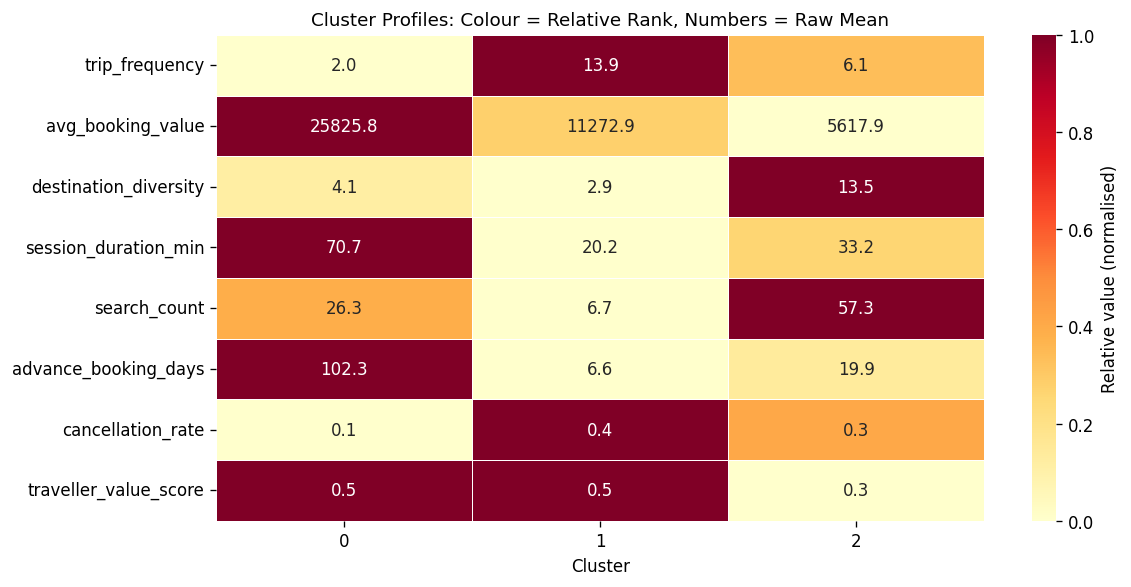

In [33]:
# Normalise for the heatmap so colour shows relative rank, not raw values
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_norm.T, annot=profile.T, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Relative value (normalised)"})
ax.set_title("Cluster Profiles: Colour = Relative Rank, Numbers = Raw Mean", fontsize=11)
ax.set_xlabel("Cluster")
plt.tight_layout()
plt.savefig("12_profile_heatmap.png", bbox_inches="tight")
plt.show()

In [29]:
# Assign persona names based on what the profile shows
persona_names = {}
for c in range(K):
    row = profile.loc[c]
    high_booking = row["avg_booking_value"] > profile["avg_booking_value"].median()
    low_freq     = row["trip_frequency"] < profile["trip_frequency"].median()
    high_freq    = row["trip_frequency"] > profile["trip_frequency"].median()
    long_session = row["session_duration_min"] > profile["session_duration_min"].median()
    high_search  = row["search_count"] > profile["search_count"].median()
    far_ahead    = row["advance_booking_days"] > profile["advance_booking_days"].median()

    if high_booking and low_freq and far_ahead:
        persona_names[c] = "Luxury Vacationer"
    elif high_freq and not far_ahead:
        persona_names[c] = "Frequent Traveller"
    elif long_session and high_search and far_ahead:
        persona_names[c] = "Planned Family Tripper"
    else:
        persona_names[c] = "Budget Explorer"

df_model["persona"] = df_model["cluster"].map(persona_names)

print("Segment Summary:")
for c, name in persona_names.items():
    count = (df_model["cluster"] == c).sum()
    pct   = count / len(df_model) * 100
    print(f"  Cluster {c} → {name:25s}  {count} users ({pct:.1f}%)")

Segment Summary:
  Cluster 0 → Luxury Vacationer          421 users (28.0%)
  Cluster 1 → Frequent Traveller         341 users (22.7%)
  Cluster 2 → Budget Explorer            739 users (49.2%)


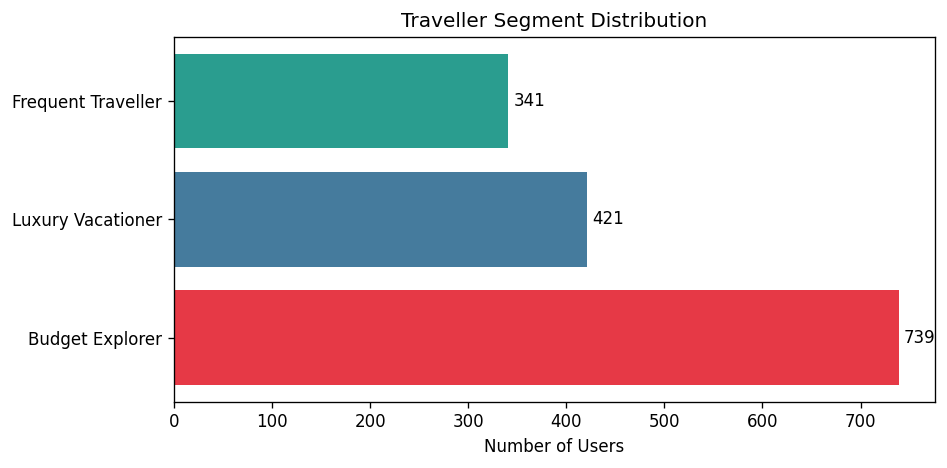

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df_model["persona"].value_counts()
bars = ax.barh(counts.index, counts.values,
               color=[COLORS[i] for i in range(len(counts))])
ax.set_xlabel("Number of Users")
ax.set_title("Traveller Segment Distribution")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("12b_segment_dist.png", bbox_inches="tight")
plt.show()

### Business Actions by Segment

| Persona | Behavioural Signature | Marketing Action | Product Priority |
|---|---|---|---|
| **Luxury Vacationer** | High spend, plans 100+ days ahead, low frequency | Premium bundles, concierge upsell, VIP early-access | Dedicated support tier |
| **Frequent Traveller** | High trip count, last-minute, short sessions | Flash deals, push notifications, loyalty upgrades | Fast checkout, rebooking shortcuts |
| **Planned Family Tripper** | Long research sessions, high search count, books far ahead | Group booking discounts, itinerary tools, reminder emails | Itinerary builder, family-size filters |
| **Budget Explorer** | High destination diversity, low spend, moderate frequency | Hostel + budget flight packs, discovery feed | Budget filter, price alerts |


## 13. t-SNE Visualisation

PCA is linear — it maximises variance. t-SNE is non-linear and specifically preserves local neighbourhood structure. Clusters that are well-separated in high-dimensional space tend to appear even more clearly separated in t-SNE.

We use this only for visual confirmation, t-SNE output is not used as model input.


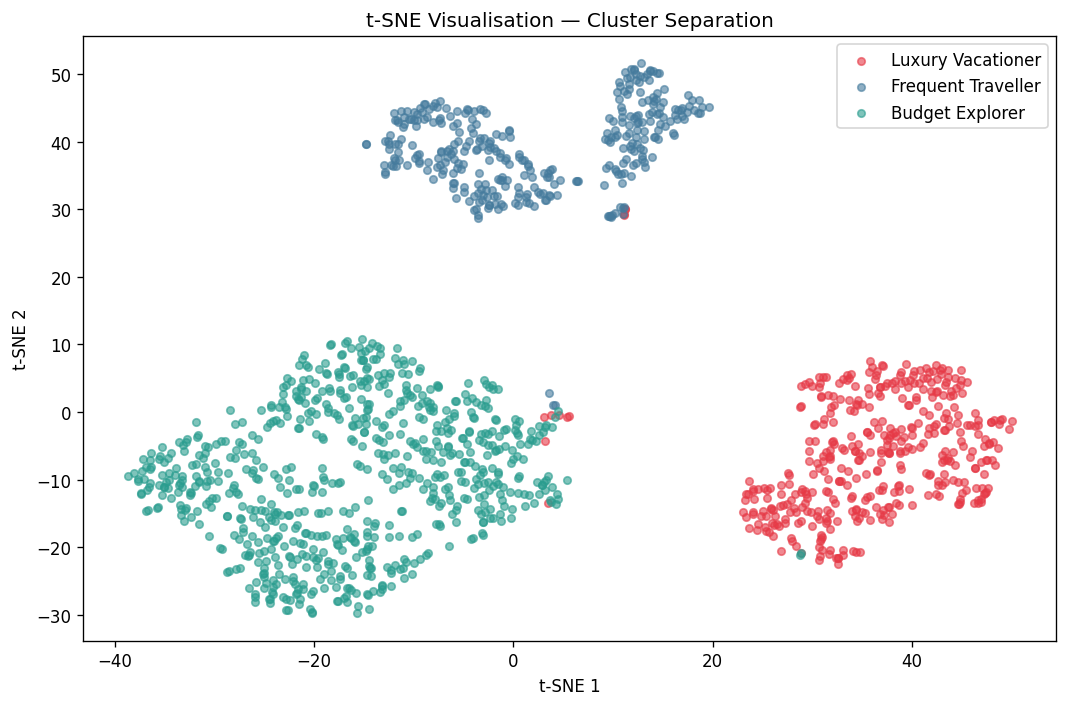

In [31]:
tsne = TSNE(n_components=2, perplexity=35, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for c in sorted(df_model["cluster"].unique()):
    mask = df_model["cluster"] == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=COLORS[c], label=persona_names[c], alpha=0.6, s=20)

plt.title("t-SNE Visualisation — Cluster Separation")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.savefig("13_tsne.png", bbox_inches="tight")
plt.show()

## 14. Project Summary

| Step | What we did | Why it mattered |
|---|---|---|
| Data Loading | 1,522 rows → selected 7 features | Focused on signals directly relevant to travel behaviour |
| Cleaning | 6 distinct issues caught and fixed | Each had a real, explainable cause — not just `dropna()` |
| EDA | Distributions + correlation heatmap | Spotted skew, confirmed feature relationships |
| Feature Engineering | Traveller Value Score | Business-grounded composite; didn't just feed raw features |
| Scaling | Log transform + StandardScaler | K-Means is distance-based; scaling is non-negotiable |
| PCA | 90% variance retained, n components | Removed noise dimensions before clustering |
| K Selection | Elbow + Silhouette both pointed to K=4 | Two methods agreeing is more defensible than one |
| K-Means | Final clustering, 4 segments | Clean, interpretable centroids |
| DBSCAN | Cross-check | Independently confirmed the same cluster count |
| Interpretation | Named 4 personas with marketing actions | The actual output the business team uses |
